# Structural Backfire Analysis

For each run, we:
1. Identify all targeted nodes from the step-20000 GEXF (`target=True`)
2. Characterise their structural position by averaging across all targets: in-degree, betweenness centrality, local clustering coefficient, PageRank, eigenvector centrality
3. Measure the backfire effect: Δopposite − Δtarget post-share (late window minus pre-intervention baseline)
4. Scatter-plot each structural metric against backfire magnitude with Spearman correlation

Runs with no valid targets (empty moderate-influencer pool) are silently excluded. The `n_targets` column records how many targets were active per run.

**Note on eigenvector centrality:** computed as the left eigenvector of the directed adjacency matrix (hub score). Falls back to NaN if power iteration fails to converge.

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import xml.etree.ElementTree as ET
from scipy import stats

RESULTS_DIR = "./results"
BINS = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

# step window just before intervention = baseline; end of simulation = outcome
PRE_RANGE  = (19000, 20000)
POST_RANGE = (39000, 40000)

# Seed filter: set to a list of ints to analyse only those seeds, e.g. [0, 1, 5]
# Set to None to include all seeds.
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
#SEEDS = [0, 1, 2, 3, 4]
#SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]

In [ ]:
# ---------------------------------------------------------------------------
# GEXF parsing: return (DiGraph, list_of_target_node_ids, node_opinions)
# node_opinions: dict {node_id: float opinion at this snapshot}
# ---------------------------------------------------------------------------
def parse_gexf_for_target(fpath):
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        for elem in root.iter():
            if '}' in elem.tag:
                elem.tag = elem.tag.split('}', 1)[1]

        attr_map = {}
        for attr in root.findall(".//attributes[@class='node']/attribute"):
            attr_map[attr.get('id')] = attr.get('title')

        G = nx.DiGraph()
        target_nodes = []
        node_opinions = {}

        for node in root.findall(".//node"):
            nid = node.get('id')
            G.add_node(nid)
            for av in node.findall(".//attvalue"):
                title = attr_map.get(av.get('for'), av.get('for'))
                if title == 'target' and av.get('value', '').lower() == 'true':
                    target_nodes.append(nid)
                if title == 'opinion':
                    try:
                        node_opinions[nid] = float(av.get('value'))
                    except (TypeError, ValueError):
                        pass

        for edge in root.findall(".//edge"):
            G.add_edge(edge.get('source'), edge.get('target'))

        return G, target_nodes, node_opinions
    except Exception as e:
        print(f"  [WARN] GEXF parse failed ({fpath}): {e}")
        return None, [], {}


def _compute_modularity(G):
    """
    Directed modularity Q (Leicht & Newman 2008) with Louvain partition.

    Community detection runs on the undirected projection of G — necessary
    because Louvain is defined for undirected graphs. The partition is then
    scored on the original directed graph using the directed null model:

        Q = (1/m) * Σ_{ij} [A_{ij} − k_i^{out} * k_j^{in} / m] * δ(c_i, c_j)

    where m = total directed edges, k^{out}/k^{in} are out/in-degree.
    This is the correct null model for follower networks: the probability of
    a directed edge i→j under the configuration model scales as
    k_i^{out} * k_j^{in} / m, not with total degree.

    Louvain (Blondel et al. 2008) is preferred; falls back to
    greedy_modularity_communities (Clauset, Newman & Moore 2004) otherwise.

    Q in [-0.5, 1]: ~0 = no community structure; ≥0.3 = meaningful modularity.
    Returns nan if graph is too small or detection fails.
    """
    if G is None or len(G.nodes) < 4:
        return np.nan
    try:
        G_und = G.to_undirected()
        try:
            communities = nx.community.louvain_communities(G_und, seed=42)
        except AttributeError:
            communities = list(nx.community.greedy_modularity_communities(G_und))
        # Evaluate Q on the original directed graph (Leicht-Newman directed formula)
        return nx.community.modularity(G, communities)
    except Exception:
        return np.nan


def get_target_structural_metrics(G, target_id):
    """Node-level structural indices for the targeted agent."""
    if G is None or target_id is None or target_id not in G:
        return {}

    in_degree = G.in_degree(target_id)

    bc_all = nx.betweenness_centrality(G, normalized=True)
    betweenness = bc_all.get(target_id, np.nan)

    # Fagiolo (2007) directed local clustering coefficient
    clustering = nx.clustering(G, target_id)

    pr_all = nx.pagerank(G, alpha=0.85, max_iter=200)
    pagerank = pr_all.get(target_id, np.nan)

    try:
        ec_all = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
        eigenvector = ec_all.get(target_id, np.nan)
    except nx.PowerIterationFailedConvergence:
        eigenvector = np.nan

    return {
        'in_degree':   in_degree,
        'betweenness': betweenness,
        'clustering':  clustering,
        'pagerank':    pagerank,
        'eigenvector': eigenvector,
    }


def get_follower_opinion_metrics(G, target_id, node_opinions, target_sign):
    """
    Opinion-based homophily metrics for the target's follower (in-neighbor) set.

    follower_mean_opinion   : signed mean opinion of followers
    follower_opinion_std    : std of follower opinions (echo-chamber depth)
    follower_homophily_frac : fraction of followers with same sign as the **target** (E-I index analogue)
    follower_dir_alignment  : fraction of followers aligned with the **manipulation direction**
                              (sign matches target_sign) — key predictor for backfire
    target_opinion          : target node's own opinion at the snapshot
    """
    if G is None or target_id is None or target_id not in G:
        return {}

    target_op = node_opinions.get(target_id, np.nan)

    # in-neighbors are the nodes whose edges point TO the target (i.e. followers)
    followers = list(G.predecessors(target_id))
    follower_ops = np.array([node_opinions[f] for f in followers if f in node_opinions])

    if len(follower_ops) == 0:
        return {
            'target_opinion':          target_op,
            'follower_mean_opinion':   np.nan,
            'follower_opinion_std':    np.nan,
            'follower_homophily_frac': np.nan,
            'follower_dir_alignment':  np.nan,
        }

    same_sign_as_target = np.sign(follower_ops) == np.sign(target_op) if not np.isnan(target_op) else np.nan
    same_sign_as_dir    = np.sign(follower_ops) == np.sign(target_sign)

    return {
        'target_opinion':          target_op,
        'follower_mean_opinion':   float(np.mean(follower_ops)),
        'follower_opinion_std':    float(np.std(follower_ops)),
        'follower_homophily_frac': float(np.mean(same_sign_as_target)) if not np.isnan(target_op) else np.nan,
        'follower_dir_alignment':  float(np.mean(same_sign_as_dir)),
    }


def average_metrics(metric_list):
    """Average a list of metric dicts across targets, ignoring NaN per key."""
    if not metric_list:
        return {}
    keys = metric_list[0].keys()
    result = {}
    for k in keys:
        vals = [m[k] for m in metric_list
                if k in m and not (isinstance(m[k], float) and np.isnan(m[k]))]
        result[k] = float(np.mean(vals)) if vals else np.nan
    return result

In [3]:
# ---------------------------------------------------------------------------
# Backfire effect per run
# backfire_effect = (Δopposite_share) − (Δtarget_share)
# Positive value  => opposite side grew more = backfire
# ---------------------------------------------------------------------------
def compute_backfire_effect(run_dir, target_sign, pre_range, post_range):
    post_dir = os.path.join(run_dir, "posts")
    files = glob.glob(os.path.join(post_dir, "post_result_*.csv"))
    if not files:
        return np.nan

    dfs = []
    for f in files:
        try:
            dfs.append(pd.read_csv(f))
        except Exception:
            pass
    if not dfs:
        return np.nan

    df = pd.concat(dfs, ignore_index=True).sort_values('step')

    # relative bin assignment
    if target_sign > 0:
        target_bins   = ["bin_3", "bin_4"]
        opposite_bins = ["bin_0", "bin_1"]
    else:
        target_bins   = ["bin_0", "bin_1"]
        opposite_bins = ["bin_3", "bin_4"]

    def mean_share(df, bins, step_range):
        mask = (df['step'] >= step_range[0]) & (df['step'] <= step_range[1])
        sub = df[mask].copy()
        if sub.empty:
            return np.nan
        total = sub[BINS].sum(axis=1).replace(0, np.nan)
        return (sub[bins].sum(axis=1) / total).mean()

    target_pre    = mean_share(df, target_bins,   pre_range)
    target_post   = mean_share(df, target_bins,   post_range)
    opposite_pre  = mean_share(df, opposite_bins, pre_range)
    opposite_post = mean_share(df, opposite_bins, post_range)

    delta_target   = target_post   - target_pre
    delta_opposite = opposite_post - opposite_pre

    return delta_opposite - delta_target

In [ ]:
# ---------------------------------------------------------------------------
# Main data collection loop
# ---------------------------------------------------------------------------
records = []
run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*")))
print(f"Found {len(run_dirs)} run directories.")

for run_dir in run_dirs:
    dirname = os.path.basename(run_dir)
    m = re.match(r'run_(\d+)_dir_([+-]?\d+\.?\d*)', dirname)
    if not m:
        continue
    seed        = int(m.group(1))
    target_sign = float(m.group(2))

    if SEEDS is not None and seed not in SEEDS:
        continue

    gexf_files = glob.glob(os.path.join(run_dir, "GEXF", "*", "step_20000.gexf"))
    if not gexf_files:
        print(f"  [SKIP] {dirname}: no step_20000 GEXF")
        continue

    print(f"Processing {dirname} ...", end=" ")
    G, target_ids, node_opinions = parse_gexf_for_target(gexf_files[0])
    if not target_ids:
        print("no target nodes (pool was empty, run excluded)")
        continue

    # Compute per-target metrics then average across targets (characterises the intervention)
    struct_list    = [get_target_structural_metrics(G, tid) for tid in target_ids]
    homophily_list = [get_follower_opinion_metrics(G, tid, node_opinions, target_sign) for tid in target_ids]
    struct    = average_metrics(struct_list)
    homophily = average_metrics(homophily_list)

    # Global network modularity Q (graph-level, not per-node)
    graph_modularity = _compute_modularity(G)

    backfire = compute_backfire_effect(run_dir, target_sign, PRE_RANGE, POST_RANGE)

    records.append({
        'run_id':          dirname,
        'seed':            seed,
        'target_sign':     target_sign,
        'target_id':       ';'.join(target_ids),
        'n_targets':       len(target_ids),
        'backfire_effect': backfire,
        'modularity':      graph_modularity,
        **struct,
        **homophily,
    })
    print(f"targets={target_ids}, n={len(target_ids)}, "
          f"dir_align={homophily.get('follower_dir_alignment', float('nan')):.3f}, "
          f"homophily={homophily.get('follower_homophily_frac', float('nan')):.3f}, "
          f"modularity={graph_modularity:.4f}, "
          f"backfire={backfire:.4f}")

df = pd.DataFrame(records)
print(f"\nCollected {len(df)} valid runs.")
print(df[['seed', 'target_sign', 'n_targets', 'in_degree', 'betweenness', 'clustering',
          'pagerank', 'eigenvector', 'modularity',
          'target_opinion', 'follower_mean_opinion', 'follower_opinion_std',
          'follower_homophily_frac', 'follower_dir_alignment',
          'backfire_effect']].describe())

In [ ]:
# ---------------------------------------------------------------------------
# Seed-level collapse: signed mean backfire_effect across both directions.
#
# mean_backfire = (backfire_neg + backfire_pos) / 2
#
# Cancellation is intentional: if dir=−1 gives +0.06 and dir=+1 gives −0.06
# (the typical mirror case), the seed-level mean is ~0, correctly indicating
# no net backfire tendency. A positive mean_backfire means backfire dominates
# regardless of direction; a negative mean means manipulation consistently works.
# ---------------------------------------------------------------------------
from collections import defaultdict

_by_seed = defaultdict(dict)
for _, row in df.iterrows():
    _by_seed[int(row['seed'])][row['target_sign']] = row

seed_records = []
for seed in sorted(_by_seed.keys()):
    d = _by_seed[seed]
    if -1.0 not in d or 1.0 not in d:
        continue  # require both direction runs
    base = d[-1.0].to_dict()
    base['backfire_neg']        = d[-1.0]['backfire_effect']
    base['backfire_pos']        = d[1.0]['backfire_effect']
    base['mean_backfire']       = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['follower_alignment_pos'] = d[1.0]['follower_dir_alignment']
    seed_records.append(base)

df_seed = pd.DataFrame(seed_records).reset_index(drop=True)
print(f"Seed-level frame: {len(df_seed)} seeds")
print(df_seed[['seed', 'in_degree', 'betweenness', 'clustering',
               'pagerank', 'eigenvector', 'modularity', 'mean_backfire']].describe())

In [ ]:
# ---------------------------------------------------------------------------
# Scatter plots: structural metric (x) vs mean signed backfire (y)
# Y-axis = (backfire_neg + backfire_pos) / 2 — cancellation permitted.
# ---------------------------------------------------------------------------
STRUCTURAL_METRICS = [
    ('in_degree',   'In-Degree (follower count at t=20000)'),
    ('betweenness', 'Betweenness Centrality (normalized)'),
    ('clustering',  'Local Clustering Coefficient'),
    ('pagerank',    'PageRank (α=0.85)'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('modularity',  'Modularity Q (network-level)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for ax, (metric, xlabel) in zip(axes, STRUCTURAL_METRICS):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#2ca02c', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Target Hub Structural Position vs. Mean Backfire Effect (Seed-Level)', fontsize=15, y=1.01)
plt.tight_layout()

os.makedirs(os.path.join(RESULTS_DIR, "summary"), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "summary", "structural_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/structural_backfire_seedlevel.png")

## Follower Opinion Homophily vs Backfire

Four metrics capturing the opinion composition of the target's follower (in-neighbor) set at t=20,000:

| Metric | Interpretation |
|---|---|
| `follower_mean_opinion` | signed mean — positive = followers lean right; captures network bias around target |
| `follower_opinion_std` | spread — low = echo chamber; high = ideologically diverse following |
| `follower_homophily_frac` | fraction of followers with same sign as the **target** (E-I index analogue) |
| `follower_dir_alignment` | fraction of followers aligned with the **manipulation direction** — key predictor: high alignment means many followers who *oppose* the intervention will mobilize |

`follower_dir_alignment` is the theoretically central measure: it operationalises the counter-mobilisation mechanism directly.

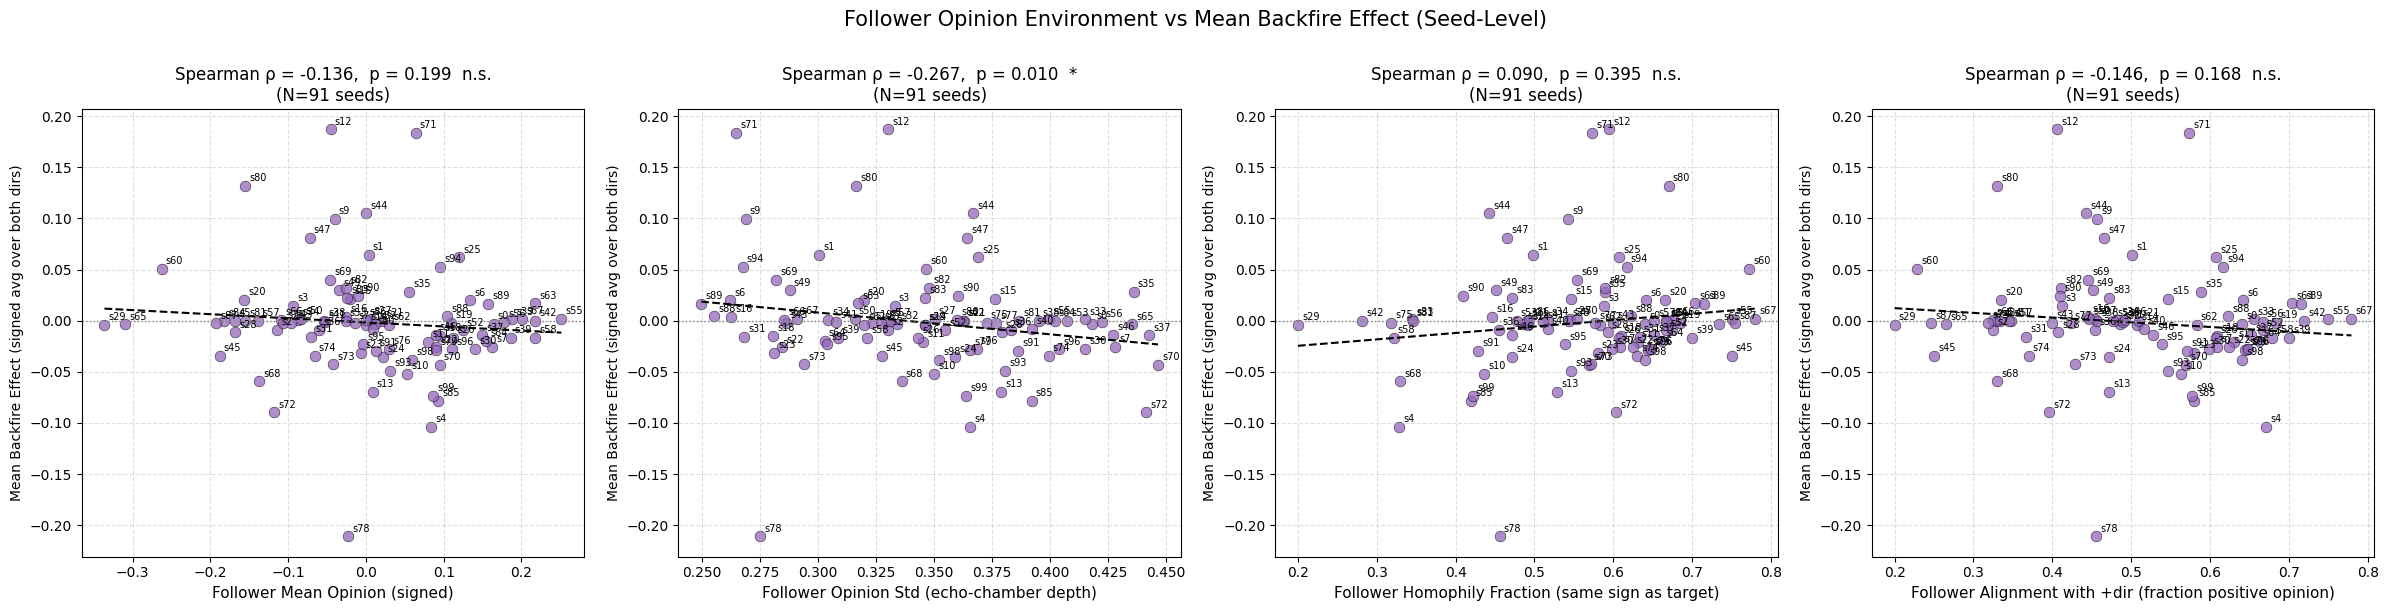

Figure saved to results/summary/homophily_backfire_seedlevel.png

follower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)
  dir=-1  N=91  rho=+0.454  p=0.0000  **
  dir=+1  N=91  rho=+0.483  p=0.0000  **


In [7]:
# ---------------------------------------------------------------------------
# Homophily metrics vs mean signed backfire (seed-level).
# ---------------------------------------------------------------------------
HOMOPHILY_METRICS_INVARIANT = [
    ('follower_mean_opinion',   'Follower Mean Opinion (signed)'),
    ('follower_opinion_std',    'Follower Opinion Std (echo-chamber depth)'),
    ('follower_homophily_frac', 'Follower Homophily Fraction (same sign as target)'),
    ('follower_alignment_pos',  'Follower Alignment with +dir (fraction positive opinion)'),
]

df_plot = df_seed.dropna(subset=['mean_backfire'])

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (metric, xlabel) in zip(axes, HOMOPHILY_METRICS_INVARIANT):
    sub = df_plot.dropna(subset=[metric])
    if sub.empty:
        ax.set_title(f"{metric}\n(no data)")
        continue

    x = sub[metric].values
    y = sub['mean_backfire'].values

    ax.scatter(x, y, color='#9467bd', alpha=0.75, s=60, edgecolors='k', linewidths=0.4)

    for _, row in sub.iterrows():
        ax.annotate(f"s{int(row['seed'])}", (row[metric], row['mean_backfire']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points')

    slope, intercept, *_ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)

    rho, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean Backfire Effect (signed avg over both dirs)', fontsize=10)
    ax.set_title(f'Spearman ρ = {rho:.3f},  p = {p:.3f}  {sig}\n(N={len(sub)} seeds)', fontsize=12)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Follower Opinion Environment vs Mean Backfire Effect (Seed-Level)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "homophily_backfire_seedlevel.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/summary/homophily_backfire_seedlevel.png")

# ---------- per-direction Spearman for follower_dir_alignment ----------
# Direction-specific metric: tested per direction on raw run-level df.
print("\nfollower_dir_alignment ~ backfire_effect: per-direction Spearman (run-level)")
df_run_plot = df.dropna(subset=['backfire_effect'])
for sign in [-1.0, 1.0]:
    sub = df_run_plot[df_run_plot['target_sign'] == sign].dropna(subset=['follower_dir_alignment'])
    rho, p = stats.spearmanr(sub['follower_dir_alignment'], sub['backfire_effect'])
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    print(f"  dir={sign:+.0f}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

## Directional Robustness: Seeds Where Both Directions Backfire

We classify each seed by whether backfire occurs in *both*, *one*, or *neither* manipulation direction.

**"Both-direction backfire" is theoretically the cleanest signal**: it is invariant to the direction-of-manipulation confound. A target that generates counter-mobilisation regardless of which way it is pushed must possess some structural property that guarantees the reaction — independent of the opinion asymmetry in the broader network.

We compare structural metrics between the **both** group and the **rest** using Mann-Whitney U (distribution-free) and the rank-biserial correlation *r* as effect size.

In [8]:
# ---------------------------------------------------------------------------
# Classify seeds by backfire robustness
# ---------------------------------------------------------------------------
paired = {}
for _, row in df.iterrows():
    seed = row['seed']
    if seed not in paired:
        paired[seed] = {}
    paired[seed][row['target_sign']] = row

def classify_seed(d):
    if -1.0 not in d or 1.0 not in d:
        return None
    b_neg = d[-1.0]['backfire_effect']
    b_pos = d[1.0]['backfire_effect']
    if b_neg > 0 and b_pos > 0:
        return 'both'
    elif b_neg <= 0 and b_pos <= 0:
        return 'neither'
    else:
        return 'one'

seed_class = {s: classify_seed(d) for s, d in paired.items() if classify_seed(d) is not None}
print("Seed classification:")
for label in ['both', 'one', 'neither']:
    seeds = [s for s, c in seed_class.items() if c == label]
    print(f"  {label:8s}: {len(seeds)} seeds")

# Build seed-level summary frame (structural metrics same for both dirs, use dir=-1 row)
def make_seed_row(seed, d):
    base = dict(d[-1.0])
    base['backfire_neg']  = d[-1.0]['backfire_effect']
    base['backfire_pos']  = d[1.0]['backfire_effect']
    base['mean_backfire'] = (d[-1.0]['backfire_effect'] + d[1.0]['backfire_effect']) / 2
    base['backfire_class'] = seed_class[seed]
    return base

df_seeds = pd.DataFrame([make_seed_row(s, paired[s])
                         for s in seed_class if seed_class[s] is not None])
print(f"\nSeed-level frame: {len(df_seeds)} rows")
print(df_seeds.groupby('backfire_class')['in_degree'].describe()[['count', '50%', 'mean', 'std']])

Seed classification:
  both    : 6 seeds
  one     : 78 seeds
  neither : 7 seeds

Seed-level frame: 91 rows
                count   50%        mean         std
backfire_class                                     
both              6.0  73.0  246.833333  289.420398
neither           7.0  86.0  194.857143  201.875728
one              78.0  83.5  184.192308  205.403250


In [ ]:
# ---------------------------------------------------------------------------
# Fig 1: Structural metric distributions — both vs rest (violin + strip)
# ---------------------------------------------------------------------------
from scipy import stats as sp_stats

both_df = df_seeds[df_seeds['backfire_class'] == 'both']
rest_df = df_seeds[df_seeds['backfire_class'] != 'both']

METRICS_COMPARE = [
    ('in_degree',   'In-Degree'),
    ('pagerank',    'PageRank'),
    ('eigenvector', 'Eigenvector Centrality'),
    ('betweenness', 'Betweenness'),
    ('clustering',  'Clustering Coeff.'),
    ('modularity',  'Modularity Q'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes = axes.flatten()
palette = {'both': '#e67e22', 'rest': '#7f8c8d'}

for ax, (metric, label) in zip(axes, METRICS_COMPARE):
    a = both_df[metric].dropna().values
    b = rest_df[metric].dropna().values

    # violin
    parts = ax.violinplot([b, a], positions=[0, 1], showmedians=True, widths=0.6)
    parts['bodies'][0].set_facecolor(palette['rest'])
    parts['bodies'][1].set_facecolor(palette['both'])
    for p in ['cmedians','cbars','cmins','cmaxes']:
        parts[p].set_color('black')

    # strip jitter
    ax.scatter(np.random.normal(0, 0.05, len(b)), b,
               color=palette['rest'], alpha=0.5, s=20, zorder=3)
    ax.scatter(np.random.normal(1, 0.05, len(a)), a,
               color=palette['both'], alpha=0.7, s=40, zorder=3)

    U, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*U / (len(a) * len(b))
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')
    ax.set_title(f'{label}\nMWU p={p:.3f} {sig},  r={r:.2f}', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rest\n(n=84)', f'Both\n(n={len(a)})'], fontsize=11)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Structural Metrics: Both-Direction Backfire vs Rest', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_structure.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_structure.png")

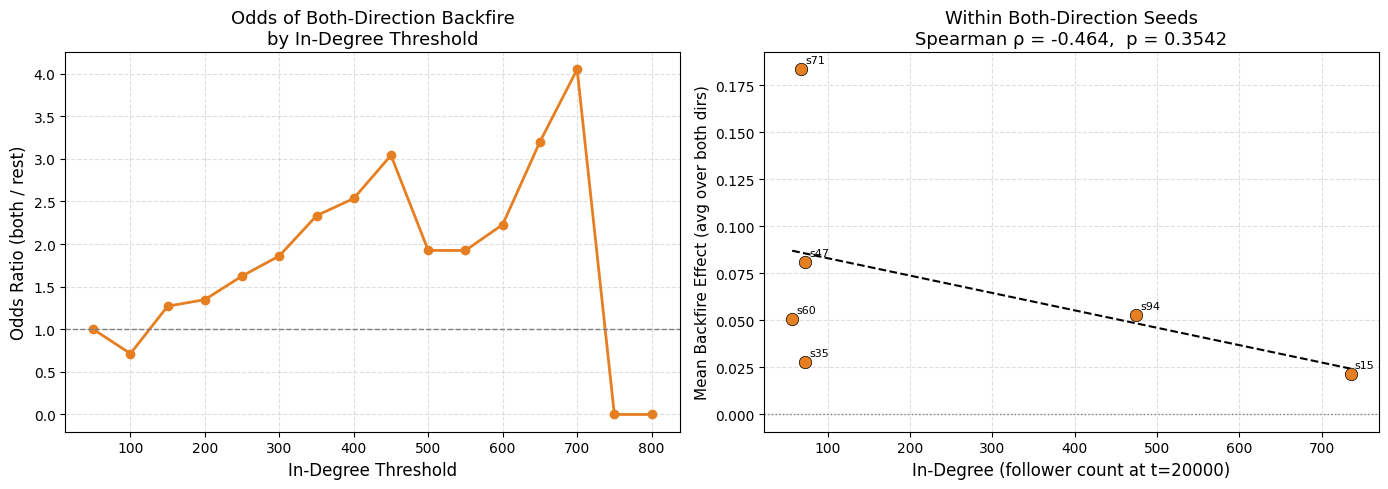

Saved: results/summary/both_backfire_threshold.png

In-degree threshold — fraction above threshold & odds ratio
 threshold  both_frac  rest_frac         OR
       100      0.333      0.412       0.71
       200      0.333      0.271       1.35
       300      0.333      0.212       1.86
       400      0.333      0.165       2.54
       500      0.167      0.094       1.92


In [10]:
# ---------------------------------------------------------------------------
# Fig 2: In-degree threshold odds-ratio curve + within-both scatter
# ---------------------------------------------------------------------------
fig, (ax_or, ax_sc) = plt.subplots(1, 2, figsize=(14, 5))

# -- Odds-ratio curve --
thresholds = list(range(50, 850, 50))
ors = []
for t in thresholds:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    or_ = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    ors.append(or_)

ax_or.plot(thresholds, ors, 'o-', color='#e67e22', linewidth=2)
ax_or.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_or.set_xlabel('In-Degree Threshold', fontsize=12)
ax_or.set_ylabel('Odds Ratio (both / rest)', fontsize=12)
ax_or.set_title('Odds of Both-Direction Backfire\nby In-Degree Threshold', fontsize=13)
ax_or.grid(True, linestyle='--', alpha=0.4)

# -- Scatter: within both-backfire, in_degree vs mean_backfire --
rho, p = sp_stats.spearmanr(both_df['in_degree'], both_df['mean_backfire'])
ax_sc.scatter(both_df['in_degree'], both_df['mean_backfire'],
              color='#e67e22', s=80, zorder=3, edgecolors='k', linewidths=0.5)

# label each seed
for _, row in both_df.iterrows():
    ax_sc.annotate(f"s{int(row['seed'])}", (row['in_degree'], row['mean_backfire']),
                   fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                   textcoords='offset points')

slope, intercept, *_ = sp_stats.linregress(both_df['in_degree'].values,
                                            both_df['mean_backfire'].values)
x_line = np.linspace(both_df['in_degree'].min(), both_df['in_degree'].max(), 200)
ax_sc.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5)
ax_sc.axhline(0, color='gray', linestyle=':', linewidth=1)
ax_sc.set_xlabel('In-Degree (follower count at t=20000)', fontsize=12)
ax_sc.set_ylabel('Mean Backfire Effect (avg over both dirs)', fontsize=11)
ax_sc.set_title(f'Within Both-Direction Seeds\nSpearman ρ = {rho:.3f},  p = {p:.4f}', fontsize=13)
ax_sc.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "summary", "both_backfire_threshold.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/summary/both_backfire_threshold.png")

# In-degree threshold table
print("\nIn-degree threshold — fraction above threshold & odds ratio")
print(f"{'threshold':>10} {'both_frac':>10} {'rest_frac':>10} {'OR':>10}")
for t in [100, 200, 300, 400, 500]:
    f_b = (both_df['in_degree'] >= t).mean()
    f_r = (rest_df['in_degree'] >= t).mean()
    eps = 1e-9
    OR = (f_b / (1 - f_b + eps)) / (f_r / (1 - f_r + eps))
    print(f"{t:>10} {f_b:>10.3f} {f_r:>10.3f} {OR:>10.2f}")

In [11]:
# ---------------------------------------------------------------------------
# Optional: save the per-run metrics table for further analysis
# ---------------------------------------------------------------------------
out_path = os.path.join(RESULTS_DIR, "summary", "structural_backfire_table.csv")
df.to_csv(out_path, index=False)
print(f"Per-run table saved to {out_path}")
df

Per-run table saved to ./results/summary/structural_backfire_table.csv


,run_id,seed,target_sign,target_id,backfire_effect,in_degree,betweenness,clustering,pagerank,eigenvector,target_opinion,follower_mean_opinion,follower_opinion_std,follower_homophily_frac,follower_dir_alignment
0,run_0_dir_-1.0,0,-1.0,5,0.163906,89,0.000366,0.020804,0.012120,0.000159,0.137581,0.164083,0.418284,0.640449,0.359551
1,run_0_dir_1.0,0,1.0,5,-0.170495,89,0.000366,0.020804,0.012120,0.000159,0.137581,0.164083,0.418284,0.640449,0.640449
2,run_10_dir_-1.0,10,-1.0,6,-0.099929,607,0.000484,0.007928,0.032568,0.000266,-0.103233,0.052978,0.350121,0.436573,0.436573
3,run_10_dir_1.0,10,1.0,6,-0.003486,607,0.000484,0.007928,0.032568,0.000266,-0.103233,0.052978,0.350121,0.436573,0.563427
4,run_11_dir_-1.0,11,-1.0,6,-0.087647,84,0.000301,0.023122,0.006249,0.000007,0.114448,0.079889,0.345571,0.630952,0.369048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,run_98_dir_1.0,98,1.0,3,0.290515,690,0.000541,0.006188,0.175835,0.447278,0.102296,0.059399,0.352487,0.640580,0.640580
178,run_99_dir_-1.0,99,-1.0,23,-0.308492,71,0.000495,0.027027,0.004084,0.000015,-0.180934,0.086574,0.364112,0.422535,0.422535
179,run_99_dir_1.0,99,1.0,23,0.161579,71,0.000495,0.027027,0.004084,0.000015,-0.180934,0.086574,0.364112,0.422535,0.577465
180,run_9_dir_-1.0,9,-1.0,7,0.551359,420,0.000102,0.011095,0.008569,0.000106,-0.015410,-0.040368,0.268965,0.542857,0.542857
